In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

OUT_DIR = Path("./nsduh_analysis_outputs")

DATA_PATH = OUT_DIR / "df_corrected_observed_target_with_gpt_profiles_embeddings.csv"

df_ml = pd.read_csv(DATA_PATH)

print("[OK] Loaded corrected dataset")
print("Shape:", df_ml.shape)
print(df_ml.columns.tolist())

print("\nYear distribution:")
print(df_ml["year"].value_counts().sort_index())

print("\nTarget distribution:")
print(df_ml["cost_barrier"].value_counts())

print("\nYear x target:")
print(pd.crosstab(df_ml["year"], df_ml["cost_barrier"]))

[OK] Loaded corrected dataset
Shape: (7227, 11)
['original_index', 'year', 'AGE3', 'NEWRACE2', 'IRINSUR4', 'substance_peer_support', 'mental_health_peer_support', 'cost_barrier', 'predictive_text', 'predictive_profile', 'predictive_embedding']

Year distribution:
year
2022    3786
2023    3441
Name: count, dtype: int64

Target distribution:
cost_barrier
1    3836
0    3391
Name: count, dtype: int64

Year x target:
cost_barrier     0     1
year                    
2022          1777  2009
2023          1614  1827


In [2]:
# 1. Build feature matrices

# GPT profile embedding
X_embed = np.vstack(
    df_ml["predictive_embedding"].apply(json.loads).values
).astype("float32")

# Target
y = df_ml["cost_barrier"].astype(int).values

# Raw structured features
raw_cols = [
    "year",
    "AGE3",
    "NEWRACE2",
    "IRINSUR4",
    "substance_peer_support",
    "mental_health_peer_support",
]

df_raw = df_ml[raw_cols].copy()

for col in raw_cols:
    df_raw[col] = df_raw[col].astype(str)

X_raw_df = pd.get_dummies(df_raw, drop_first=False)
X_raw = X_raw_df.values.astype("float32")

# Combined
X_combined = np.hstack([X_raw, X_embed]).astype("float32")

print("X_raw:", X_raw.shape)
print("X_embed:", X_embed.shape)
print("X_combined:", X_combined.shape)
print("y:", y.shape)
print("Target counts:", np.bincount(y))

X_raw: (7227, 26)
X_embed: (7227, 1536)
X_combined: (7227, 1562)
y: (7227,)
Target counts: [3391 3836]


In [3]:
from sklearn.model_selection import train_test_split

indices = np.arange(len(df_ml))

train_pool_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train pool size:", len(train_pool_idx))
print("Fixed test size:", len(test_idx))

print("Train pool target counts:", np.bincount(y[train_pool_idx]))
print("Fixed test target counts:", np.bincount(y[test_idx]))

Train pool size: 5781
Fixed test size: 1446
Train pool target counts: [2713 3068]
Fixed test target counts: [678 768]


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

def evaluate_predictions(y_true, y_pred, y_score):
    return {
        "AUC": roc_auc_score(y_true, y_score),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
    }


def train_and_eval_model(model_name, feature_name, X_train, X_test, y_train, y_test):
    if model_name == "Logistic Regression":
        model = LogisticRegression(
            max_iter=2000,
            solver="saga",
            n_jobs=-1,
            class_weight="balanced",
            random_state=42,
        )
    
    elif model_name == "Random Forest":
        model = RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=5,
            n_jobs=-1,
            class_weight="balanced",
            random_state=42,
        )
    
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    
    result = evaluate_predictions(y_test, y_pred, y_score)
    result["Model"] = model_name
    result["Feature"] = feature_name
    
    return result

In [6]:
train_sizes = [50, 100, 200, 500, 1000, 2000, 4000, len(train_pool_idx)]

In [7]:
print("df_ml shape:", df_ml.shape)
print("Expected corrected sample was 7970")

df_ml shape: (7227, 11)
Expected corrected sample was 7970


In [8]:
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

candidate_train_sizes = [50, 100, 200, 500, 1000, 2000, 4000, len(train_pool_idx)]

train_sizes = [
    s for s in candidate_train_sizes
    if s <= len(train_pool_idx)
]

base_seeds = [0, 1, 2, 3, 4]

feature_sets = {
    "Raw structured": X_raw,
    "GPT profile embedding": X_embed,
    "Raw + GPT profile embedding": X_combined,
}

model_names = [
    "Logistic Regression",
    "Random Forest",
]

all_results = []

y_test = y[test_idx]

for train_size in train_sizes:
    print(f"\n========== Train size: {train_size} ==========")
    
    # Full train pool은 seed 반복 불필요
    if train_size == len(train_pool_idx):
        seeds_for_this_size = [0]
    else:
        seeds_for_this_size = base_seeds
    
    for seed in seeds_for_this_size:
        
        if train_size == len(train_pool_idx):
            sampled_train_idx = train_pool_idx
        else:
            sampled_train_idx, _ = train_test_split(
                train_pool_idx,
                train_size=train_size,
                random_state=seed,
                stratify=y[train_pool_idx],
            )
        
        y_train = y[sampled_train_idx]
        
        for feature_name, X in feature_sets.items():
            X_train = X[sampled_train_idx]
            X_test = X[test_idx]
            
            for model_name in model_names:
                try:
                    result = train_and_eval_model(
                        model_name=model_name,
                        feature_name=feature_name,
                        X_train=X_train,
                        X_test=X_test,
                        y_train=y_train,
                        y_test=y_test,
                    )
                    
                    result["Train Size"] = train_size
                    result["Seed"] = seed
                    all_results.append(result)
                    
                    print(
                        f"size={train_size}, seed={seed}, "
                        f"{model_name}, {feature_name}, "
                        f"AUC={result['AUC']:.4f}"
                    )
                    
                except Exception as e:
                    print(
                        f"[ERROR] size={train_size}, seed={seed}, "
                        f"{model_name}, {feature_name}: {e}"
                    )

learning_curve_df = pd.DataFrame(all_results)

learning_curve_df.to_csv(
    OUT_DIR / "learning_curve_corrected_target_raw_gpt_embedding.csv",
    index=False
)

print("[DONE] Saved learning curve results")
learning_curve_df.head()

/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



========== Train size: 50 ==========
size=50, seed=0, Logistic Regression, Raw structured, AUC=0.5119
size=50, seed=0, Random Forest, Raw structured, AUC=0.4633
size=50, seed=0, Logistic Regression, GPT profile embedding, AUC=0.4831


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


size=50, seed=0, Random Forest, GPT profile embedding, AUC=0.5024
size=50, seed=0, Logistic Regression, Raw + GPT profile embedding, AUC=0.5112


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


...

/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


size=5781, seed=0, Logistic Regression, GPT profile embedding, AUC=0.6244
size=5781, seed=0, Random Forest, GPT profile embedding, AUC=0.5923


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


size=5781, seed=0, Logistic Regression, Raw + GPT profile embedding, AUC=0.6285
size=5781, seed=0, Random Forest, Raw + GPT profile embedding, AUC=0.5923
[DONE] Saved learning curve results


,AUC,Accuracy,Balanced Accuracy,F1,Precision,Recall,Model,Feature,Train Size,Seed
0,0.511921,0.528354,0.520557,0.592593,0.547461,0.645833,Logistic Regression,Raw structured,50,0
1,0.463258,0.486169,0.479201,0.549970,0.514156,0.591146,Random Forest,Raw structured,50,0
2,0.483066,0.511065,0.503071,0.578414,0.533553,0.631510,Logistic Regression,GPT profile embedding,50,0
3,0.502433,0.511065,0.506873,0.555066,0.537150,0.574219,Random Forest,GPT profile embedding,50,0
4,0.511215,0.529046,0.521208,0.593433,0.547960,0.647135,Logistic Regression,Raw + GPT profile embedding,50,0


In [10]:
summary_df = (
    learning_curve_df
    .groupby(["Train Size", "Model", "Feature"])
    .agg(
        AUC_mean=("AUC", "mean"),
        AUC_std=("AUC", "std"),
        Accuracy_mean=("Accuracy", "mean"),
        Balanced_Accuracy_mean=("Balanced Accuracy", "mean"),
        F1_mean=("F1", "mean"),
        Precision_mean=("Precision", "mean"),
        Recall_mean=("Recall", "mean"),
        n_runs=("AUC", "count"),
    )
    .reset_index()
)

summary_df = summary_df.sort_values(
    ["Train Size", "Model", "AUC_mean"],
    ascending=[True, True, False]
)

summary_df

,Train Size,Model,Feature,AUC_mean,AUC_std,Accuracy_mean,Balanced_Accuracy_mean,F1_mean,Precision_mean,Recall_mean,n_runs
2,50,Logistic Regression,Raw structured,0.537217,0.030708,0.534855,0.534420,0.550541,0.566986,0.541406,5
1,50,Logistic Regression,Raw + GPT profile embedding,0.536997,0.030308,0.535408,0.535235,0.549302,0.568122,0.538021,5
0,50,Logistic Regression,GPT profile embedding,0.530850,0.037903,0.529322,0.526844,0.558323,0.556041,0.566667,5
4,50,Random Forest,Raw + GPT profile embedding,0.531997,0.032586,0.527939,0.524833,0.563535,0.554955,0.574740,5
3,50,Random Forest,GPT profile embedding,0.531315,0.033697,0.526141,0.524074,0.554476,0.555027,0.557292,5
5,50,Random Forest,Raw structured,0.519642,0.036627,0.513416,0.508966,0.556684,0.538580,0.580469,5
8,100,Logistic Regression,Raw structured,0.596290,0.023769,0.563347,0.562902,0.576461,0.595082,0.570052,5
7,100,Logistic Regression,Raw + GPT profile embedding,0.595467,0.023764,0.564177,0.563666,0.577732,0.595737,0.571875,5
6,100,Logistic Regression,GPT profile embedding,0.588536,0.020240,0.570678,0.567764,0.601296,0.593866,0.614583,5
11,100,Random Forest,Raw structured,0.588717,0.017868,0.562517,0.562881,0.570361,0.597925,0.557031,5


In [12]:
auc_pivot = summary_df.pivot_table(
    index=["Train Size", "Model"],
    columns="Feature",
    values="AUC_mean"
).reset_index()

auc_pivot["GPT_minus_Raw"] = (
    auc_pivot["GPT profile embedding"] - auc_pivot["Raw structured"]
)

auc_pivot["Combined_minus_Raw"] = (
    auc_pivot["Raw + GPT profile embedding"] - auc_pivot["Raw structured"]
)

auc_pivot.to_csv(
    OUT_DIR / "learning_curve_corrected_target_auc_comparison.csv",
    index=False
)

auc_pivot

Feature,Train Size,Model,GPT profile embedding,Raw + GPT profile embedding,Raw structured,GPT_minus_Raw,Combined_minus_Raw
0,50,Logistic Regression,0.530850,0.536997,0.537217,-0.006368,-0.000221
1,50,Random Forest,0.531315,0.531997,0.519642,0.011672,0.012355
2,100,Logistic Regression,0.588536,0.595467,0.596290,-0.007755,-0.000823
3,100,Random Forest,0.562512,0.560862,0.588717,-0.026205,-0.027855
4,200,Logistic Regression,0.597153,0.606865,0.607122,-0.009969,-0.000257
5,200,Random Forest,0.567309,0.566330,0.609645,-0.042337,-0.043315
6,500,Logistic Regression,0.610409,0.615625,0.616629,-0.006220,-0.001004
7,500,Random Forest,0.569699,0.569967,0.615743,-0.046044,-0.045776
8,1000,Logistic Regression,0.615379,0.622244,0.623480,-0.008101,-0.001236
9,1000,Random Forest,0.579750,0.578916,0.618998,-0.039248,-0.040081


In [15]:
df_ml.shape

(7227, 11)

In [14]:
from pathlib import Path
import pandas as pd

OUT_DIR = Path("./nsduh_analysis_outputs")

# 1) df_ml이 corrected target dataset 

# 2) 기존 GPT + embedding 전체 파일
df_final = pd.read_csv(
    OUT_DIR / "df_profile_with_gpt41_profiles_and_embeddings.csv"
)

print("df_model_corrected:", df_ml.shape)
print("df_final:", df_final.shape)

print("original_index in df_model_corrected?", "original_index" in df_ml.columns)
print("original_index in df_final?", "original_index" in df_final.columns)

corrected_ids = set(df_ml["original_index"])
embedded_ids = set(df_final["original_index"])

missing_ids = corrected_ids - embedded_ids
extra_ids = embedded_ids - corrected_ids

print("Corrected rows:", len(corrected_ids))
print("Embedded rows:", len(embedded_ids))
print("Corrected rows missing from embedding file:", len(missing_ids))
print("Embedding rows not in corrected sample:", len(extra_ids))

df_model_corrected: (7227, 11)
df_final: (123943, 11)
original_index in df_model_corrected? True
original_index in df_final? True
Corrected rows: 7227
Embedded rows: 123943
Corrected rows missing from embedding file: 0
Embedding rows not in corrected sample: 116716


In [16]:
import pandas as pd
import numpy as np
from pathlib import Path

OUT_DIR = Path("./nsduh_analysis_outputs")

# df_small이 없으면 다시 불러오기
df_small = pd.read_csv(OUT_DIR / "df_small_from_raw.csv")

print(df_small.shape)
print(df_small.columns.tolist())

(232441, 14)
['year', 'AGE3', 'NEWRACE2', 'IRINSUR4', 'irsutpeerspc', 'irmhtpeerspc', 'hlnvcost', 'sutuncost', 'suntcost', 'mhtuncost', 'mhntcost', 'cost_barrier', 'substance_peer_support', 'mental_health_peer_support']


In [17]:
target_cost_cols = [
    "sutuncost",
    "suntcost",
    "mhtuncost",
    "mhntcost",
]

def normalize_value(x):
    if pd.isna(x):
        return np.nan
    return str(x).strip().lower()

def is_target_yes(x):
    s = normalize_value(x)
    if pd.isna(s):
        return False
    
    if s in ["1", "1.0"]:
        return True
    
    if s.startswith("1") and "yes" in s:
        return True
    
    if "1 - yes" in s:
        return True
    
    return False

def is_target_no(x):
    s = normalize_value(x)
    if pd.isna(s):
        return False
    
    if s in ["0", "0.0", "2", "2.0"]:
        return True
    
    if s.startswith("0") and "no" in s:
        return True
    
    if s.startswith("2") and "no" in s:
        return True
    
    if "0 - no" in s or "2 - no" in s:
        return True
    
    return False

def make_cost_barrier_corrected(row):
    values = [row[c] for c in target_cost_cols]
    
    # If any explicit Yes, target = 1
    if any(is_target_yes(v) for v in values):
        return 1
    
    # Keep only explicit Yes/No values
    valid_binary_values = [
        v for v in values
        if is_target_yes(v) or is_target_no(v)
    ]
    
    # If no observed Yes/No target info, target is missing
    if len(valid_binary_values) == 0:
        return np.nan
    
    # If there is at least one explicit No and no Yes, target = 0
    if all(is_target_no(v) for v in valid_binary_values):
        return 0
    
    return np.nan

df_small["cost_barrier_corrected"] = df_small.apply(
    make_cost_barrier_corrected,
    axis=1
)

print("[OK] Corrected target created")

print("\nOverall corrected target:")
print(df_small["cost_barrier_corrected"].value_counts(dropna=False))

print("\nYear x corrected target:")
print(pd.crosstab(df_small["year"], df_small["cost_barrier_corrected"], dropna=False))

print("\nYear x corrected target normalized:")
print(
    pd.crosstab(
        df_small["year"],
        df_small["cost_barrier_corrected"],
        normalize="index",
        dropna=False
    )
)

[OK] Corrected target created

Overall corrected target:
cost_barrier_corrected
NaN    224471
0.0      4134
1.0      3836
Name: count, dtype: int64

Year x corrected target:
cost_barrier_corrected   0.0   1.0    NaN
year                                     
2021                       0     0  58034
2022                    2201  2009  54859
2023                    1933  1827  52945
2024                       0     0  58633

Year x corrected target normalized:
cost_barrier_corrected       0.0       1.0       NaN
year                                                
2021                    0.000000  0.000000  1.000000
2022                    0.037262  0.034011  0.928727
2023                    0.034089  0.032219  0.933692
2024                    0.000000  0.000000  1.000000


In [18]:
model_cols = [
    "year",
    "AGE3",
    "NEWRACE2",
    "IRINSUR4",
    "substance_peer_support",
    "mental_health_peer_support",
    "cost_barrier_corrected",
]

df_model_corrected = df_small[model_cols].copy()

# original_index 보존
df_model_corrected = df_model_corrected.reset_index(drop=False).rename(
    columns={"index": "original_index"}
)

# observed target만 남기기
df_model_corrected = df_model_corrected.dropna(
    subset=["cost_barrier_corrected"]
).copy()

df_model_corrected["cost_barrier"] = df_model_corrected["cost_barrier_corrected"].astype(int)
df_model_corrected = df_model_corrected.drop(columns=["cost_barrier_corrected"])

print("[OK] df_model_corrected created")
print("Shape:", df_model_corrected.shape)

print("\nYear distribution:")
print(df_model_corrected["year"].value_counts(dropna=False).sort_index())

print("\nTarget distribution:")
print(df_model_corrected["cost_barrier"].value_counts(dropna=False))

print("\nYear x target:")
print(pd.crosstab(df_model_corrected["year"], df_model_corrected["cost_barrier"]))

print("\nYear x target normalized:")
print(
    pd.crosstab(
        df_model_corrected["year"],
        df_model_corrected["cost_barrier"],
        normalize="index"
    )
)

[OK] df_model_corrected created
Shape: (7970, 8)

Year distribution:
year
2022    4210
2023    3760
Name: count, dtype: int64

Target distribution:
cost_barrier
0    4134
1    3836
Name: count, dtype: int64

Year x target:
cost_barrier     0     1
year                    
2022          2201  2009
2023          1933  1827

Year x target normalized:
cost_barrier         0         1
year                            
2022          0.522803  0.477197
2023          0.514096  0.485904


In [19]:
FINAL_EMBED_PATH = OUT_DIR / "df_profile_with_gpt41_profiles_and_embeddings.csv"

df_final = pd.read_csv(FINAL_EMBED_PATH)

print("[OK] Loaded previous GPT/embedding file")
print("df_final shape:", df_final.shape)
print(df_final.columns.tolist())

print("original_index in df_final?", "original_index" in df_final.columns)
print("original_index in df_model_corrected?", "original_index" in df_model_corrected.columns)

[OK] Loaded previous GPT/embedding file
df_final shape: (123943, 11)
['original_index', 'year', 'AGE3', 'NEWRACE2', 'IRINSUR4', 'substance_peer_support', 'mental_health_peer_support', 'cost_barrier', 'predictive_text', 'predictive_profile', 'predictive_embedding']
original_index in df_final? True
original_index in df_model_corrected? True


In [20]:
df_corrected = df_model_corrected.merge(
    df_final[
        [
            "original_index",
            "predictive_text",
            "predictive_profile",
            "predictive_embedding",
        ]
    ],
    on="original_index",
    how="inner"
)

print("[OK] Corrected dataset merged with GPT profiles/embeddings")
print("Shape:", df_corrected.shape)

print("\nMissing predictive_profile:")
print(df_corrected["predictive_profile"].isna().sum())

print("\nMissing predictive_embedding:")
print(df_corrected["predictive_embedding"].isna().sum())

print("\nYear x target:")
print(pd.crosstab(df_corrected["year"], df_corrected["cost_barrier"]))

print("\nYear x target normalized:")
print(
    pd.crosstab(
        df_corrected["year"],
        df_corrected["cost_barrier"],
        normalize="index"
    )
)

# df_corrected.to_csv(
#     OUT_DIR / "df_corrected_observed_target_with_gpt_profiles_embeddings.csv",
#     index=False
# )

# print("[DONE] Saved corrected dataset")

[OK] Corrected dataset merged with GPT profiles/embeddings
Shape: (7227, 11)

Missing predictive_profile:
0

Missing predictive_embedding:
0

Year x target:
cost_barrier     0     1
year                    
2022          1777  2009
2023          1614  1827

Year x target normalized:
cost_barrier         0         1
year                            
2022          0.469361  0.530639
2023          0.469050  0.530950


In [21]:
merge_check = df_model_corrected.merge(
    df_final[
        [
            "original_index",
            "predictive_text",
            "predictive_profile",
            "predictive_embedding",
        ]
    ],
    on="original_index",
    how="left",
    indicator=True
)

print(merge_check["_merge"].value_counts())

df_missing = merge_check[merge_check["_merge"] == "left_only"].copy()

print("Missing rows:", df_missing.shape)

print("\nMissing year distribution:")
print(df_missing["year"].value_counts().sort_index())

print("\nMissing target distribution:")
print(df_missing["cost_barrier"].value_counts())

print("\nMissing year x target:")
print(pd.crosstab(df_missing["year"], df_missing["cost_barrier"]))

_merge
both          7227
left_only      743
right_only       0
Name: count, dtype: int64
Missing rows: (743, 12)

Missing year distribution:
year
2022    424
2023    319
Name: count, dtype: int64

Missing target distribution:
cost_barrier
0    743
Name: count, dtype: int64

Missing year x target:
cost_barrier    0
year             
2022          424
2023          319


In [22]:
# df_model_corrected: corrected target 전체 7,970명이어야 함
# df_final: 기존 GPT profile + embedding 파일

merge_check = df_model_corrected.merge(
    df_final[
        [
            "original_index",
            "predictive_text",
            "predictive_profile",
            "predictive_embedding",
        ]
    ],
    on="original_index",
    how="left",
    indicator=True
)

print(merge_check["_merge"].value_counts())

df_missing = merge_check[merge_check["_merge"] == "left_only"].copy()

print("Missing rows:", df_missing.shape)

print("\nColumns in missing rows:")
print(df_missing.columns.tolist())

print("\nMissing predictive_text:")
print(df_missing["predictive_text"].isna().sum())

print("\nMissing predictive_profile:")
print(df_missing["predictive_profile"].isna().sum())

print("\nMissing predictive_embedding:")
print(df_missing["predictive_embedding"].isna().sum())

_merge
both          7227
left_only      743
right_only       0
Name: count, dtype: int64
Missing rows: (743, 12)

Columns in missing rows:
['original_index', 'year', 'AGE3', 'NEWRACE2', 'IRINSUR4', 'substance_peer_support', 'mental_health_peer_support', 'cost_barrier', 'predictive_text', 'predictive_profile', 'predictive_embedding', '_merge']

Missing predictive_text:
743

Missing predictive_profile:
743

Missing predictive_embedding:
743


In [23]:
# 빠진 743명에 대해 predictive_text 다시 만들기

def make_predictive_text(row):
    return (
        f"This respondent was surveyed in {row['year']}. "
        f"The respondent's age category is {row['AGE3']}. "
        f"The respondent's race/ethnicity category is {row['NEWRACE2']}. "
        f"The respondent's insurance status is {row['IRINSUR4']}. "
        f"For substance use peer support, the response is {row['substance_peer_support']}. "
        f"For mental health peer support, the response is {row['mental_health_peer_support']}."
    )

df_missing_for_gpt = df_missing[
    [
        "original_index",
        "year",
        "AGE3",
        "NEWRACE2",
        "IRINSUR4",
        "substance_peer_support",
        "mental_health_peer_support",
        "cost_barrier",
    ]
].copy()

df_missing_for_gpt["predictive_text"] = df_missing_for_gpt.apply(
    make_predictive_text,
    axis=1
)

print(df_missing_for_gpt.shape)
print(df_missing_for_gpt[["original_index", "year", "cost_barrier", "predictive_text"]].head())

(743, 9)
    original_index  year  cost_barrier  \
32           58383  2022             0   
34           58424  2022             0   
36           58431  2022             0   
39           58453  2022             0   
40           58471  2022             0   

                                      predictive_text  
32  This respondent was surveyed in 2022. The resp...  
34  This respondent was surveyed in 2022. The resp...  
36  This respondent was surveyed in 2022. The resp...  
39  This respondent was surveyed in 2022. The resp...  
40  This respondent was surveyed in 2022. The resp...  


In [25]:
!pip install openai

In [26]:
import os

if not os.environ.get("OPENAI_API_KEY"):
    raise RuntimeError("Set the OPENAI_API_KEY environment variable before running this notebook.")

In [27]:
# 빠진 743명만 GPT profile 생성

from openai import OpenAI
from pathlib import Path
import pandas as pd
import time

client = OpenAI(timeout=60.0, max_retries=2)

OUT_DIR = Path("./nsduh_analysis_outputs")

MISSING_PROFILE_CHECKPOINT = OUT_DIR / "df_missing_743_with_gpt_profiles_checkpoint.csv"
MISSING_PROFILE_OUTPUT = OUT_DIR / "df_missing_743_with_gpt_profiles.csv"

MODEL_NAME = "gpt-4.1-mini"

SYSTEM_PROMPT = """
You are assisting with an academic machine learning study using NSDUH survey variables.

Your task is to rewrite structured survey information into a concise, neutral respondent profile.

Important rules:
- Do NOT predict the target label.
- Do NOT mention whether the respondent has or does not have a cost barrier.
- Do NOT add facts that are not provided.
- Do NOT infer sensitive traits beyond the given survey categories.
- Preserve uncertainty when information is unavailable, missing, or not collected.
- Keep the profile concise, factual, and suitable for downstream text embedding.
- Write in 2 to 4 sentences.
"""

def build_user_prompt(predictive_text):
    return f"""
Structured survey information:

{predictive_text}

Rewrite this into a concise predictive profile for downstream machine learning.
"""

def generate_predictive_profile(predictive_text, max_retries=5):
    if pd.isna(predictive_text) or str(predictive_text).strip() == "":
        return ""

    user_prompt = build_user_prompt(str(predictive_text))

    for attempt in range(max_retries):
        try:
            response = client.responses.create(
                model=MODEL_NAME,
                input=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": user_prompt},
                ],
                temperature=0,
                max_output_tokens=180,
                timeout=60,
            )

            return response.output_text.strip()

        except Exception as e:
            wait_time = min(2 ** attempt, 60)
            print(f"[WARN] API error attempt {attempt + 1}/{max_retries}: {e}")
            print(f"[INFO] Waiting {wait_time} seconds...")
            time.sleep(wait_time)

    return ""


# Resume or start
if MISSING_PROFILE_CHECKPOINT.exists():
    df_missing_work = pd.read_csv(MISSING_PROFILE_CHECKPOINT)
    print("[INFO] Resuming missing profiles checkpoint")
else:
    df_missing_work = df_missing_for_gpt.copy()
    df_missing_work["predictive_profile"] = ""
    print("[INFO] Starting missing profiles generation")

mask_todo = (
    df_missing_work["predictive_profile"].isna()
    | (df_missing_work["predictive_profile"].astype(str).str.strip() == "")
    | (df_missing_work["predictive_profile"].astype(str).str.lower().str.strip() == "nan")
)

todo_indices = df_missing_work.index[mask_todo].tolist()

print("Total missing rows:", len(df_missing_work))
print("Rows to generate:", len(todo_indices))

SAVE_EVERY = 25

for n, idx in enumerate(todo_indices, start=1):
    text = df_missing_work.loc[idx, "predictive_text"]
    profile = generate_predictive_profile(text)
    df_missing_work.loc[idx, "predictive_profile"] = profile

    if n % SAVE_EVERY == 0:
        df_missing_work.to_csv(MISSING_PROFILE_CHECKPOINT, index=False)
        print(f"[CHECKPOINT] Saved after {n} rows")

df_missing_work.to_csv(MISSING_PROFILE_CHECKPOINT, index=False)
df_missing_work.to_csv(MISSING_PROFILE_OUTPUT, index=False)

print("[DONE] Missing GPT profiles generated")
print(df_missing_work["predictive_profile"].isna().sum())

[INFO] Starting missing profiles generation
Total missing rows: 743
Rows to generate: 743
[CHECKPOINT] Saved after 25 rows
[CHECKPOINT] Saved after 50 rows
[CHECKPOINT] Saved after 75 rows
[CHECKPOINT] Saved after 100 rows
[CHECKPOINT] Saved after 125 rows
[CHECKPOINT] Saved after 150 rows
[CHECKPOINT] Saved after 175 rows
[CHECKPOINT] Saved after 200 rows
[CHECKPOINT] Saved after 225 rows
[CHECKPOINT] Saved after 250 rows
[CHECKPOINT] Saved after 275 rows
[CHECKPOINT] Saved after 300 rows
[CHECKPOINT] Saved after 325 rows
[CHECKPOINT] Saved after 350 rows
[CHECKPOINT] Saved after 375 rows
[CHECKPOINT] Saved after 400 rows
[CHECKPOINT] Saved after 425 rows
[CHECKPOINT] Saved after 450 rows
[CHECKPOINT] Saved after 475 rows
[CHECKPOINT] Saved after 500 rows
[CHECKPOINT] Saved after 525 rows
[CHECKPOINT] Saved after 550 rows
[CHECKPOINT] Saved after 575 rows
[CHECKPOINT] Saved after 600 rows
[CHECKPOINT] Saved after 625 rows
[CHECKPOINT] Saved after 650 rows
[CHECKPOINT] Saved after 675 

In [32]:
from pathlib import Path
import pandas as pd

OUT_DIR = Path("./nsduh_analysis_outputs")

df_missing_profiles = pd.read_csv(
    OUT_DIR / "df_missing_743_with_gpt_profiles.csv"
)

print(df_missing_profiles.shape)
print(df_missing_profiles.columns.tolist())

(743, 10)
['original_index', 'year', 'AGE3', 'NEWRACE2', 'IRINSUR4', 'substance_peer_support', 'mental_health_peer_support', 'cost_barrier', 'predictive_text', 'predictive_profile']


In [33]:
# 743명 embedding 생성 코드

import json
import time
import pandas as pd
from pathlib import Path
from openai import OpenAI

OUT_DIR = Path("./nsduh_analysis_outputs")

PROFILE_INPUT = OUT_DIR / "df_missing_743_with_gpt_profiles.csv"
EMBED_CHECKPOINT = OUT_DIR / "df_missing_743_with_gpt_profiles_embeddings_checkpoint.csv"
EMBED_OUTPUT = OUT_DIR / "df_missing_743_with_gpt_profiles_embeddings.csv"

client = OpenAI(timeout=120.0, max_retries=2)

EMBED_MODEL = "text-embedding-3-small"

# Resume or start
if EMBED_CHECKPOINT.exists():
    print("[INFO] Resuming from embedding checkpoint")
    df_missing_embed = pd.read_csv(EMBED_CHECKPOINT)
else:
    print("[INFO] Starting embeddings from profile file")
    df_missing_embed = pd.read_csv(PROFILE_INPUT)
    df_missing_embed["predictive_embedding"] = None

print("Shape:", df_missing_embed.shape)
print("Columns:", df_missing_embed.columns.tolist())

def get_embeddings_batch(texts, max_retries=5):
    clean_texts = [
        "" if pd.isna(t) else str(t)
        for t in texts
    ]

    for attempt in range(max_retries):
        try:
            response = client.embeddings.create(
                model=EMBED_MODEL,
                input=clean_texts,
                timeout=120,
            )
            return [item.embedding for item in response.data]

        except Exception as e:
            wait_time = min(2 ** attempt, 60)
            print(f"[WARN] Embedding error attempt {attempt + 1}/{max_retries}: {e}")
            print(f"[INFO] Waiting {wait_time} seconds...")
            time.sleep(wait_time)

    return [None] * len(texts)

mask_todo = (
    df_missing_embed["predictive_embedding"].isna()
    | (df_missing_embed["predictive_embedding"].astype(str).str.strip() == "")
    | (df_missing_embed["predictive_embedding"].astype(str).str.lower().str.strip() == "none")
    | (df_missing_embed["predictive_embedding"].astype(str).str.lower().str.strip() == "nan")
)

todo_indices = df_missing_embed.index[mask_todo].tolist()

print("Rows to embed:", len(todo_indices))

BATCH_SIZE = 128

batches = [
    todo_indices[i:i + BATCH_SIZE]
    for i in range(0, len(todo_indices), BATCH_SIZE)
]

for batch_num, batch_indices in enumerate(batches, start=1):
    texts = df_missing_embed.loc[batch_indices, "predictive_profile"].tolist()
    embeddings = get_embeddings_batch(texts)

    for idx, emb in zip(batch_indices, embeddings):
        if emb is not None:
            df_missing_embed.at[idx, "predictive_embedding"] = json.dumps(emb)

    df_missing_embed.to_csv(EMBED_CHECKPOINT, index=False)
    print(f"[CHECKPOINT] Saved batch {batch_num}/{len(batches)}")

df_missing_embed.to_csv(EMBED_CHECKPOINT, index=False)
df_missing_embed.to_csv(EMBED_OUTPUT, index=False)

print("[DONE] Missing 743 embeddings generated")
print("Saved:", EMBED_OUTPUT)
print("Missing embeddings:", df_missing_embed["predictive_embedding"].isna().sum())

[INFO] Starting embeddings from profile file
Shape: (743, 11)
Columns: ['original_index', 'year', 'AGE3', 'NEWRACE2', 'IRINSUR4', 'substance_peer_support', 'mental_health_peer_support', 'cost_barrier', 'predictive_text', 'predictive_profile', 'predictive_embedding']
Rows to embed: 743
[CHECKPOINT] Saved batch 1/6
[CHECKPOINT] Saved batch 2/6
[CHECKPOINT] Saved batch 3/6
[CHECKPOINT] Saved batch 4/6
[CHECKPOINT] Saved batch 5/6
[CHECKPOINT] Saved batch 6/6
[DONE] Missing 743 embeddings generated
Saved: nsduh_analysis_outputs/df_missing_743_with_gpt_profiles_embeddings.csv
Missing embeddings: 0


In [34]:
import pandas as pd
from pathlib import Path

OUT_DIR = Path("./nsduh_analysis_outputs")

df_final = pd.read_csv(
    OUT_DIR / "df_profile_with_gpt41_profiles_and_embeddings.csv"
)

df_missing_completed = pd.read_csv(
    OUT_DIR / "df_missing_743_with_gpt_profiles_embeddings.csv"
)

print("df_final columns:")
print(df_final.columns.tolist())

print("\ndf_missing_completed columns:")
print(df_missing_completed.columns.tolist())

cols_to_keep = [
    "original_index",
    "predictive_text",
    "predictive_profile",
    "predictive_embedding",
]

df_final_augmented = pd.concat(
    [
        df_final[cols_to_keep],
        df_missing_completed[cols_to_keep],
    ],
    ignore_index=True
)

df_final_augmented = df_final_augmented.drop_duplicates(
    subset=["original_index"],
    keep="first"
)

print("Original df_final:", df_final.shape)
print("Missing completed:", df_missing_completed.shape)
print("Augmented df_final:", df_final_augmented.shape)

df_final_augmented.to_csv(
    OUT_DIR / "df_profile_with_gpt41_profiles_and_embeddings_augmented.csv",
    index=False
)

print("[DONE] Saved augmented embedding file")

df_final columns:
['original_index', 'year', 'AGE3', 'NEWRACE2', 'IRINSUR4', 'substance_peer_support', 'mental_health_peer_support', 'cost_barrier', 'predictive_text', 'predictive_profile', 'predictive_embedding']

df_missing_completed columns:
['original_index', 'year', 'AGE3', 'NEWRACE2', 'IRINSUR4', 'substance_peer_support', 'mental_health_peer_support', 'cost_barrier', 'predictive_text', 'predictive_profile', 'predictive_embedding']
Original df_final: (123943, 11)
Missing completed: (743, 11)
Augmented df_final: (124686, 4)
[DONE] Saved augmented embedding file


In [35]:
df_corrected_full = df_model_corrected.merge(
    df_final_augmented[
        [
            "original_index",
            "predictive_text",
            "predictive_profile",
            "predictive_embedding",
        ]
    ],
    on="original_index",
    how="inner"
)

print("[OK] Corrected full dataset merged")
print("Shape:", df_corrected_full.shape)

print("\nMissing predictive_profile:")
print(df_corrected_full["predictive_profile"].isna().sum())

print("\nMissing predictive_embedding:")
print(df_corrected_full["predictive_embedding"].isna().sum())

print("\nYear x target:")
print(pd.crosstab(df_corrected_full["year"], df_corrected_full["cost_barrier"]))

df_corrected_full.to_csv(
    OUT_DIR / "df_corrected_7970_with_gpt_profiles_embeddings.csv",
    index=False
)

print("[DONE] Saved full corrected 7970 dataset")

[OK] Corrected full dataset merged
Shape: (7970, 11)

Missing predictive_profile:
0

Missing predictive_embedding:
0

Year x target:
cost_barrier     0     1
year                    
2022          2201  2009
2023          1933  1827
[DONE] Saved full corrected 7970 dataset


In [36]:
# 0. Full corrected 7970 dataset load

from pathlib import Path
import json
import numpy as np
import pandas as pd

OUT_DIR = Path("./nsduh_analysis_outputs")

DATA_PATH = OUT_DIR / "df_corrected_7970_with_gpt_profiles_embeddings.csv"

df_ml = pd.read_csv(DATA_PATH)

print("[OK] Loaded full corrected dataset")
print("Shape:", df_ml.shape)
print(df_ml.columns.tolist())

print("\nMissing predictive_profile:")
print(df_ml["predictive_profile"].isna().sum())

print("\nMissing predictive_embedding:")
print(df_ml["predictive_embedding"].isna().sum())

print("\nYear distribution:")
print(df_ml["year"].value_counts().sort_index())

print("\nTarget distribution:")
print(df_ml["cost_barrier"].value_counts())

print("\nYear x target:")
print(pd.crosstab(df_ml["year"], df_ml["cost_barrier"]))

print("\nYear x target normalized:")
print(
    pd.crosstab(
        df_ml["year"],
        df_ml["cost_barrier"],
        normalize="index"
    )
)

[OK] Loaded full corrected dataset
Shape: (7970, 11)
['original_index', 'year', 'AGE3', 'NEWRACE2', 'IRINSUR4', 'substance_peer_support', 'mental_health_peer_support', 'cost_barrier', 'predictive_text', 'predictive_profile', 'predictive_embedding']

Missing predictive_profile:
0

Missing predictive_embedding:
0

Year distribution:
year
2022    4210
2023    3760
Name: count, dtype: int64

Target distribution:
cost_barrier
0    4134
1    3836
Name: count, dtype: int64

Year x target:
cost_barrier     0     1
year                    
2022          2201  2009
2023          1933  1827

Year x target normalized:
cost_barrier         0         1
year                            
2022          0.522803  0.477197
2023          0.514096  0.485904


In [37]:
# 1. Build feature matrices

# GPT profile embedding
X_embed = np.vstack(
    df_ml["predictive_embedding"].apply(json.loads).values
).astype("float32")

# Target
y = df_ml["cost_barrier"].astype(int).values

# Raw structured features
raw_cols = [
    "year",
    "AGE3",
    "NEWRACE2",
    "IRINSUR4",
    "substance_peer_support",
    "mental_health_peer_support",
]

df_raw = df_ml[raw_cols].copy()

for col in raw_cols:
    df_raw[col] = df_raw[col].astype(str)

X_raw_df = pd.get_dummies(df_raw, drop_first=False)
X_raw = X_raw_df.values.astype("float32")

# Combined
X_combined = np.hstack([X_raw, X_embed]).astype("float32")

print("X_raw:", X_raw.shape)
print("X_embed:", X_embed.shape)
print("X_combined:", X_combined.shape)
print("y:", y.shape)
print("Target counts:", np.bincount(y))

X_raw: (7970, 26)
X_embed: (7970, 1536)
X_combined: (7970, 1562)
y: (7970,)
Target counts: [4134 3836]


In [38]:
# 2. Fixed train/test split

from sklearn.model_selection import train_test_split

indices = np.arange(len(df_ml))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(train_idx))
print("Test size:", len(test_idx))

print("Train target counts:", np.bincount(y[train_idx]))
print("Test target counts:", np.bincount(y[test_idx]))

Train size: 6376
Test size: 1594
Train target counts: [3307 3069]
Test target counts: [827 767]


In [40]:
# 3. Evaluation 함수

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
)

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    print(f"\n[INFO] Training {name}...")
    
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    result = {
        "Model": name,
        "AUC": roc_auc_score(y_test, y_score),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
    }

    print("[DONE]", name)
    print(result)
    print("\nClassification report:")
    print(classification_report(y_test, y_pred))

    return result

In [41]:
# 4. Full train/test baseline 
X_raw_train = X_raw[train_idx]
X_raw_test = X_raw[test_idx]

X_embed_train = X_embed[train_idx]
X_embed_test = X_embed[test_idx]

X_combined_train = X_combined[train_idx]
X_combined_test = X_combined[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

results = []

# Logistic Regression
logreg_raw = LogisticRegression(
    max_iter=2000,
    solver="saga",
    n_jobs=-1,
    class_weight="balanced",
    random_state=42,
)

logreg_embed = LogisticRegression(
    max_iter=2000,
    solver="saga",
    n_jobs=-1,
    class_weight="balanced",
    random_state=42,
)

logreg_combined = LogisticRegression(
    max_iter=2000,
    solver="saga",
    n_jobs=-1,
    class_weight="balanced",
    random_state=42,
)

results.append(
    evaluate_model(
        "Logistic Regression - Raw structured full corrected",
        logreg_raw,
        X_raw_train,
        X_raw_test,
        y_train,
        y_test,
    )
)

results.append(
    evaluate_model(
        "Logistic Regression - GPT profile embedding full corrected",
        logreg_embed,
        X_embed_train,
        X_embed_test,
        y_train,
        y_test,
    )
)

results.append(
    evaluate_model(
        "Logistic Regression - Raw + GPT profile embedding full corrected",
        logreg_combined,
        X_combined_train,
        X_combined_test,
        y_train,
        y_test,
    )
)

# Random Forest
rf_raw = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=5,
    n_jobs=-1,
    class_weight="balanced",
    random_state=42,
)

rf_embed = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=5,
    n_jobs=-1,
    class_weight="balanced",
    random_state=42,
)

rf_combined = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=5,
    n_jobs=-1,
    class_weight="balanced",
    random_state=42,
)

results.append(
    evaluate_model(
        "Random Forest - Raw structured full corrected",
        rf_raw,
        X_raw_train,
        X_raw_test,
        y_train,
        y_test,
    )
)

results.append(
    evaluate_model(
        "Random Forest - GPT profile embedding full corrected",
        rf_embed,
        X_embed_train,
        X_embed_test,
        y_train,
        y_test,
    )
)

results.append(
    evaluate_model(
        "Random Forest - Raw + GPT profile embedding full corrected",
        rf_combined,
        X_combined_train,
        X_combined_test,
        y_train,
        y_test,
    )
)

results_df = pd.DataFrame(results).sort_values("AUC", ascending=False)

results_df.to_csv(
    OUT_DIR / "ml_results_full_corrected_7970.csv",
    index=False
)

results_df


[INFO] Training Logistic Regression - Raw structured full corrected...


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


[DONE] Logistic Regression - Raw structured full corrected
{'Model': 'Logistic Regression - Raw structured full corrected', 'AUC': 0.6872076543135915, 'Accuracy': 0.6430363864491845, 'Balanced Accuracy': 0.644303486155801, 'F1': 0.6463642013673089, 'Precision': 0.6175771971496437, 'Recall': 0.6779661016949152}

Classification report:
              precision    recall  f1-score   support

           0       0.67      0.61      0.64       827
           1       0.62      0.68      0.65       767

    accuracy                           0.64      1594
   macro avg       0.64      0.64      0.64      1594
weighted avg       0.65      0.64      0.64      1594


[INFO] Training Logistic Regression - GPT profile embedding full corrected...


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


[DONE] Logistic Regression - GPT profile embedding full corrected
{'Model': 'Logistic Regression - GPT profile embedding full corrected', 'AUC': 0.7197272937952953, 'Accuracy': 0.6593475533249686, 'Balanced Accuracy': 0.6606850919662184, 'F1': 0.6629422718808193, 'Precision': 0.6327014218009479, 'Recall': 0.6962190352020861}

Classification report:
              precision    recall  f1-score   support

           0       0.69      0.63      0.66       827
           1       0.63      0.70      0.66       767

    accuracy                           0.66      1594
   macro avg       0.66      0.66      0.66      1594
weighted avg       0.66      0.66      0.66      1594


[INFO] Training Logistic Regression - Raw + GPT profile embedding full corrected...


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


[DONE] Logistic Regression - Raw + GPT profile embedding full corrected
{'Model': 'Logistic Regression - Raw + GPT profile embedding full corrected', 'AUC': 0.7216869065392418, 'Accuracy': 0.6656210790464241, 'Balanced Accuracy': 0.6670148145462227, 'F1': 0.6695598264104153, 'Precision': 0.6382978723404256, 'Recall': 0.7040417209908736}

Classification report:
              precision    recall  f1-score   support

           0       0.70      0.63      0.66       827
           1       0.64      0.70      0.67       767

    accuracy                           0.67      1594
   macro avg       0.67      0.67      0.67      1594
weighted avg       0.67      0.67      0.67      1594


[INFO] Training Random Forest - Raw structured full corrected...
[DONE] Random Forest - Raw structured full corrected
{'Model': 'Random Forest - Raw structured full corrected', 'AUC': 0.6789750736628363, 'Accuracy': 0.6442910915934755, 'Balanced Accuracy': 0.6450397203886434, 'F1': 0.6427221172022685, 'Preci

,Model,AUC,Accuracy,Balanced Accuracy,F1,Precision,Recall
2,Logistic Regression - Raw + GPT profile embedd...,0.721687,0.665621,0.667015,0.669560,0.638298,0.704042
1,Logistic Regression - GPT profile embedding fu...,0.719727,0.659348,0.660685,0.662942,0.632701,0.696219
4,Random Forest - GPT profile embedding full cor...,0.690550,0.647428,0.649340,0.656479,0.617952,0.700130
5,Random Forest - Raw + GPT profile embedding fu...,0.690198,0.644918,0.646827,0.654034,0.615650,0.697523
0,Logistic Regression - Raw structured full corr...,0.687208,0.643036,0.644303,0.646364,0.617577,0.677966
3,Random Forest - Raw structured full corrected,0.678975,0.644291,0.645040,0.642722,0.621951,0.664928


In [42]:
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split


# 5. Low-data learning curve on full corrected sample
train_pool_idx = train_idx
fixed_test_idx = test_idx

print("Train pool size:", len(train_pool_idx))
print("Fixed test size:", len(fixed_test_idx))
print("Train pool target counts:", np.bincount(y[train_pool_idx]))
print("Fixed test target counts:", np.bincount(y[fixed_test_idx]))

candidate_train_sizes = [
    50,
    100,
    200,
    500,
    1000,
    2000,
    4000,
    len(train_pool_idx),
]

train_sizes = [
    s for s in candidate_train_sizes
    if s <= len(train_pool_idx)
]

print("Train sizes:", train_sizes)

base_seeds = [0, 1, 2, 3, 4]

feature_sets = {
    "Raw structured": X_raw,
    "GPT profile embedding": X_embed,
    "Raw + GPT profile embedding": X_combined,
}

model_names = [
    "Logistic Regression",
    "Random Forest",
]

def train_and_eval_model(model_name, feature_name, X_train, X_test, y_train, y_test):
    if model_name == "Logistic Regression":
        model = LogisticRegression(
            max_iter=2000,
            solver="saga",
            n_jobs=-1,
            class_weight="balanced",
            random_state=42,
        )

    elif model_name == "Random Forest":
        model = RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=5,
            n_jobs=-1,
            class_weight="balanced",
            random_state=42,
        )

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    result = {
        "AUC": roc_auc_score(y_test, y_score),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "Model": model_name,
        "Feature": feature_name,
    }

    return result


all_results = []

y_test_fixed = y[fixed_test_idx]

for train_size in train_sizes:
    print(f"\n========== Train size: {train_size} ==========")

    # Full train pool은 seed 반복 불필요
    if train_size == len(train_pool_idx):
        seeds_for_this_size = [0]
    else:
        seeds_for_this_size = base_seeds

    for seed in seeds_for_this_size:

        if train_size == len(train_pool_idx):
            sampled_train_idx = train_pool_idx
        else:
            sampled_train_idx, _ = train_test_split(
                train_pool_idx,
                train_size=train_size,
                random_state=seed,
                stratify=y[train_pool_idx],
            )

        y_train_sample = y[sampled_train_idx]

        for feature_name, X in feature_sets.items():
            X_train_sample = X[sampled_train_idx]
            X_test_fixed = X[fixed_test_idx]

            for model_name in model_names:
                try:
                    result = train_and_eval_model(
                        model_name=model_name,
                        feature_name=feature_name,
                        X_train=X_train_sample,
                        X_test=X_test_fixed,
                        y_train=y_train_sample,
                        y_test=y_test_fixed,
                    )

                    result["Train Size"] = train_size
                    result["Seed"] = seed
                    all_results.append(result)

                    print(
                        f"size={train_size}, seed={seed}, "
                        f"{model_name}, {feature_name}, "
                        f"AUC={result['AUC']:.4f}"
                    )

                except Exception as e:
                    print(
                        f"[ERROR] size={train_size}, seed={seed}, "
                        f"{model_name}, {feature_name}: {e}"
                    )

learning_curve_df = pd.DataFrame(all_results)

learning_curve_df.to_csv(
    OUT_DIR / "learning_curve_full_corrected_7970_raw_gpt_embedding.csv",
    index=False,
)

print("[DONE] Saved full corrected learning curve results")
learning_curve_df.head()

Train pool size: 6376
Fixed test size: 1594
Train pool target counts: [3307 3069]
Fixed test target counts: [827 767]
Train sizes: [50, 100, 200, 500, 1000, 2000, 4000, 6376]

========== Train size: 50 ==========
size=50, seed=0, Logistic Regression, Raw structured, AUC=0.5932


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


size=50, seed=0, Random Forest, Raw structured, AUC=0.5469
size=50, seed=0, Logistic Regression, GPT profile embedding, AUC=0.5866


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


size=50, seed=0, Random Forest, GPT profile embedding, AUC=0.5522
size=50, seed=0, Logistic Regression, Raw + GPT profile embedding, AUC=0.5924


...

/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


size=6376, seed=0, Logistic Regression, GPT profile embedding, AUC=0.7197
size=6376, seed=0, Random Forest, GPT profile embedding, AUC=0.6905


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


size=6376, seed=0, Logistic Regression, Raw + GPT profile embedding, AUC=0.7217
size=6376, seed=0, Random Forest, Raw + GPT profile embedding, AUC=0.6902
[DONE] Saved full corrected learning curve results


,AUC,Accuracy,Balanced Accuracy,F1,Precision,Recall,Model,Feature,Train Size,Seed
0,0.593171,0.585320,0.588255,0.607249,0.557860,0.666232,Logistic Regression,Raw structured,50,0
1,0.546917,0.520075,0.518661,0.491018,0.501359,0.481095,Random Forest,Raw structured,50,0
2,0.586566,0.565245,0.567158,0.577697,0.542334,0.617992,Logistic Regression,GPT profile embedding,50,0
3,0.552170,0.563363,0.563878,0.560051,0.543558,0.577575,Random Forest,GPT profile embedding,50,0
4,0.592423,0.580301,0.583418,0.604376,0.553030,0.666232,Logistic Regression,Raw + GPT profile embedding,50,0


In [43]:
# 6. Summary for the Learninv curve
summary_df = (
    learning_curve_df
    .groupby(["Train Size", "Model", "Feature"])
    .agg(
        AUC_mean=("AUC", "mean"),
        AUC_std=("AUC", "std"),
        Accuracy_mean=("Accuracy", "mean"),
        Balanced_Accuracy_mean=("Balanced Accuracy", "mean"),
        F1_mean=("F1", "mean"),
        Precision_mean=("Precision", "mean"),
        Recall_mean=("Recall", "mean"),
        n_runs=("AUC", "count"),
    )
    .reset_index()
)

summary_df = summary_df.sort_values(
    ["Train Size", "Model", "AUC_mean"],
    ascending=[True, True, False],
)

summary_df.to_csv(
    OUT_DIR / "learning_curve_full_corrected_7970_summary.csv",
    index=False,
)

summary_df

,Train Size,Model,Feature,AUC_mean,AUC_std,Accuracy_mean,Balanced_Accuracy_mean,F1_mean,Precision_mean,Recall_mean,n_runs
0,50,Logistic Regression,GPT profile embedding,0.618363,0.064661,0.593099,0.594314,0.598180,0.575551,0.626597,5
1,50,Logistic Regression,Raw + GPT profile embedding,0.586099,0.036096,0.557465,0.558157,0.554092,0.538477,0.576532,5
2,50,Logistic Regression,Raw structured,0.578723,0.034240,0.557340,0.557961,0.552886,0.537956,0.574446,5
4,50,Random Forest,Raw + GPT profile embedding,0.601379,0.048351,0.573149,0.574237,0.576143,0.555806,0.603129,5
3,50,Random Forest,GPT profile embedding,0.597951,0.051566,0.574404,0.575210,0.573986,0.557478,0.596610,5
5,50,Random Forest,Raw structured,0.527696,0.017577,0.505897,0.504610,0.477577,0.487272,0.470404,5
6,100,Logistic Regression,GPT profile embedding,0.683746,0.021431,0.638519,0.639373,0.636995,0.615730,0.662060,5
7,100,Logistic Regression,Raw + GPT profile embedding,0.657458,0.020520,0.621832,0.620860,0.602128,0.609624,0.595046,5
8,100,Logistic Regression,Raw structured,0.646152,0.019894,0.616311,0.615417,0.597160,0.603181,0.591656,5
10,100,Random Forest,Raw + GPT profile embedding,0.657420,0.031781,0.615684,0.614982,0.599179,0.602943,0.596349,5


In [44]:
# 7. GPT vs Raw Comparison

auc_pivot = summary_df.pivot_table(
    index=["Train Size", "Model"],
    columns="Feature",
    values="AUC_mean",
).reset_index()

auc_pivot["GPT_minus_Raw"] = (
    auc_pivot["GPT profile embedding"] - auc_pivot["Raw structured"]
)

auc_pivot["Combined_minus_Raw"] = (
    auc_pivot["Raw + GPT profile embedding"] - auc_pivot["Raw structured"]
)

auc_pivot.to_csv(
    OUT_DIR / "learning_curve_full_corrected_7970_auc_comparison.csv",
    index=False,
)

auc_pivot

Feature,Train Size,Model,GPT profile embedding,Raw + GPT profile embedding,Raw structured,GPT_minus_Raw,Combined_minus_Raw
0,50,Logistic Regression,0.618363,0.586099,0.578723,0.039640,0.007377
1,50,Random Forest,0.597951,0.601379,0.527696,0.070255,0.073683
2,100,Logistic Regression,0.683746,0.657458,0.646152,0.037595,0.011306
3,100,Random Forest,0.654580,0.657420,0.626307,0.028274,0.031114
4,200,Logistic Regression,0.693025,0.672946,0.661314,0.031711,0.011632
5,200,Random Forest,0.655648,0.657157,0.649540,0.006108,0.007617
6,500,Logistic Regression,0.702587,0.696277,0.676748,0.025839,0.019529
7,500,Random Forest,0.660923,0.661470,0.670081,-0.009158,-0.008611
8,1000,Logistic Regression,0.710972,0.705966,0.680491,0.030481,0.025475
9,1000,Random Forest,0.673206,0.673199,0.671224,0.001982,0.001975


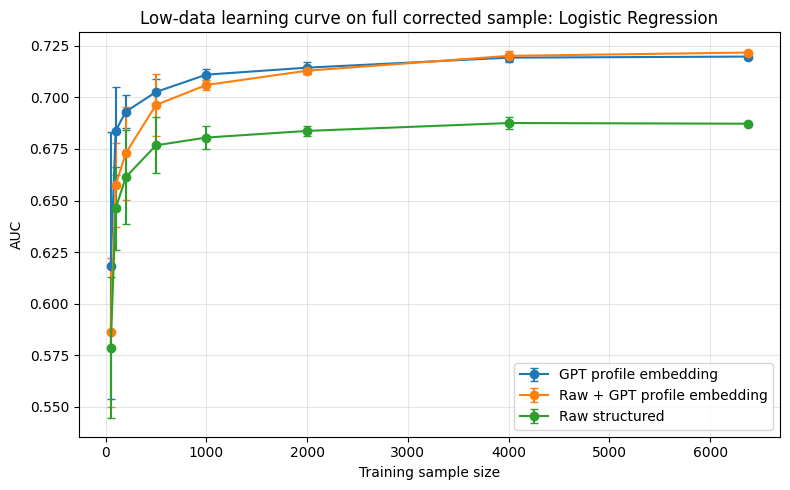

Saved: nsduh_analysis_outputs/learning_curve_full_corrected_7970_logistic_regression.png


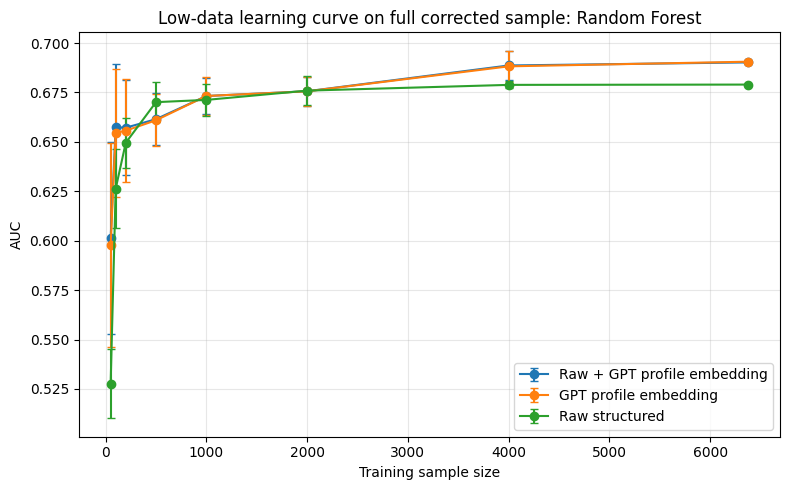

Saved: nsduh_analysis_outputs/learning_curve_full_corrected_7970_random_forest.png


In [45]:
# Saving Plot

import matplotlib.pyplot as plt

plot_df = summary_df.copy()

for model_name in plot_df["Model"].unique():
    temp_model = plot_df[plot_df["Model"] == model_name]

    plt.figure(figsize=(8, 5))

    for feature_name in temp_model["Feature"].unique():
        temp = temp_model[temp_model["Feature"] == feature_name].sort_values("Train Size")

        plt.errorbar(
            temp["Train Size"],
            temp["AUC_mean"],
            yerr=temp["AUC_std"],
            marker="o",
            capsize=3,
            label=feature_name,
        )

    plt.xlabel("Training sample size")
    plt.ylabel("AUC")
    plt.title(f"Low-data learning curve on full corrected sample: {model_name}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    save_path = OUT_DIR / f"learning_curve_full_corrected_7970_{model_name.replace(' ', '_').lower()}.png"

    plt.savefig(save_path, dpi=300)
    plt.show()

    print("Saved:", save_path)

In [46]:
import numpy as np
import pandas as pd

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
)

# Optional XGBoost
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception as e:
    HAS_XGB = False
    print("[INFO] XGBoost not available:", e)


feature_sets = {
    "Raw structured": X_raw,
    "GPT profile embedding": X_embed,
    "Raw + GPT profile embedding": X_combined,
}

X_train_test = {}

for feature_name, X in feature_sets.items():
    X_train_test[feature_name] = {
        "X_train": X[train_idx],
        "X_test": X[test_idx],
    }

y_train = y[train_idx]
y_test = y[test_idx]


def get_score(model, X_test):
    """
    Return continuous score for AUC.
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        return model.decision_function(X_test)
    else:
        # fallback; not ideal for AUC, but avoids crash
        return model.predict(X_test)


def evaluate_model_general(model_name, feature_name, model, X_train, X_test, y_train, y_test):
    print(f"\n[INFO] Training {model_name} | {feature_name}")
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_score = get_score(model, X_test)

    result = {
        "Model": model_name,
        "Feature": feature_name,
        "AUC": roc_auc_score(y_test, y_score),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
    }

    print(result)
    return result

In [ ]:
# B. Model Factory

def make_model(model_name):
    if model_name == "Logistic Regression":
        return make_pipeline(
            StandardScaler(),
            LogisticRegression(
                max_iter=3000,
                solver="saga",
                class_weight="balanced",
                n_jobs=-1,
                random_state=42,
            )
        )

    elif model_name == "Linear SVM":
        return make_pipeline(
            StandardScaler(),
            LinearSVC(
                class_weight="balanced",
                max_iter=5000,
                random_state=42,
            )
        )

    elif model_name == "Ridge Classifier":
        return make_pipeline(
            StandardScaler(),
            RidgeClassifier(
                class_weight="balanced",
                random_state=42,
            )
        )

    elif model_name == "Random Forest":
        return RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=5,
            n_jobs=-1,
            class_weight="balanced",
            random_state=42,
        )

    elif model_name == "Extra Trees":
        return ExtraTreesClassifier(
            n_estimators=300,
            min_samples_leaf=5,
            n_jobs=-1,
            class_weight="balanced",
            random_state=42,
        )

    elif model_name == "HistGradientBoosting":
        return HistGradientBoostingClassifier(
            max_iter=300,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=0.01,
            random_state=42,
        )

    elif model_name == "XGBoost":
        if not HAS_XGB:
            raise RuntimeError("XGBoost is not installed.")
        
        return XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            n_jobs=-1,
            random_state=42,
        )

    else:
        raise ValueError(f"Unknown model: {model_name}")

In [48]:
# C. The whole model

model_names = [
    "Logistic Regression",
    "Linear SVM",
    "Ridge Classifier",
    "Random Forest",
    "Extra Trees",
    "HistGradientBoosting",
]

if HAS_XGB:
    model_names.append("XGBoost")

all_model_results = []

for model_name in model_names:
    for feature_name, data in X_train_test.items():
        try:
            model = make_model(model_name)
            
            result = evaluate_model_general(
                model_name=model_name,
                feature_name=feature_name,
                model=model,
                X_train=data["X_train"],
                X_test=data["X_test"],
                y_train=y_train,
                y_test=y_test,
            )
            
            all_model_results.append(result)

        except Exception as e:
            print(f"[ERROR] {model_name} | {feature_name}: {e}")

all_models_df = pd.DataFrame(all_model_results)
all_models_df = all_models_df.sort_values("AUC", ascending=False)

all_models_df.to_csv(
    OUT_DIR / "ml_results_full_corrected_7970_all_classifiers.csv",
    index=False,
)

all_models_df


[INFO] Training Logistic Regression | Raw structured
{'Model': 'Logistic Regression', 'Feature': 'Raw structured', 'AUC': 0.6871296166379478, 'Accuracy': 0.6430363864491845, 'Balanced Accuracy': 0.644303486155801, 'F1': 0.6463642013673089, 'Precision': 0.6175771971496437, 'Recall': 0.6779661016949152}

[INFO] Training Logistic Regression | GPT profile embedding


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided '

{'Model': 'Logistic Regression', 'Feature': 'GPT profile embedding', 'AUC': 0.6978097425702615, 'Accuracy': 0.64366373902133, 'Balanced Accuracy': 0.6464215390290853, 'F1': 0.6602870813397129, 'Precision': 0.6099447513812155, 'Recall': 0.7196870925684485}

[INFO] Training Logistic Regression | Raw + GPT profile embedding


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


{'Model': 'Logistic Regression', 'Feature': 'Raw + GPT profile embedding', 'AUC': 0.6959723100255553, 'Accuracy': 0.6468005018820577, 'Balanced Accuracy': 0.6494445136360985, 'F1': 0.6622675464907019, 'Precision': 0.6133333333333333, 'Recall': 0.7196870925684485}

[INFO] Training Linear SVM | Raw structured
{'Model': 'Linear SVM', 'Feature': 'Raw structured', 'AUC': 0.6865470929783434, 'Accuracy': 0.6442910915934755, 'Balanced Accuracy': 0.6457018582425915, 'F1': 0.6489164086687307, 'Precision': 0.6179245283018868, 'Recall': 0.6831812255541069}

[INFO] Training Linear SVM | GPT profile embedding
{'Model': 'Linear SVM', 'Feature': 'GPT profile embedding', 'AUC': 0.6854876724120263, 'Accuracy': 0.6455457967377666, 'Balanced Accuracy': 0.647715072622334, 'F1': 0.6569520340012144, 'Precision': 0.6147727272727272, 'Recall': 0.7053455019556715}

[INFO] Training Linear SVM | Raw + GPT profile embedding
{'Model': 'Linear SVM', 'Feature': 'Raw + GPT profile embedding', 'AUC': 0.6826499387522484

/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.1821451312575846e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


{'Model': 'Ridge Classifier', 'Feature': 'GPT profile embedding', 'AUC': 0.6863058856172621, 'Accuracy': 0.6424090338770388, 'Balanced Accuracy': 0.6447866891373132, 'F1': 0.6557971014492754, 'Precision': 0.6107986501687289, 'Recall': 0.7079530638852672}

[INFO] Training Ridge Classifier | Raw + GPT profile embedding


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.152057554383191e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


{'Model': 'Ridge Classifier', 'Feature': 'Raw + GPT profile embedding', 'AUC': 0.683997862240643, 'Accuracy': 0.6411543287327478, 'Balanced Accuracy': 0.6434829081725153, 'F1': 0.6541717049576784, 'Precision': 0.6099210822998873, 'Recall': 0.7053455019556715}

[INFO] Training Random Forest | Raw structured
{'Model': 'Random Forest', 'Feature': 'Raw structured', 'AUC': 0.6789750736628363, 'Accuracy': 0.6442910915934755, 'Balanced Accuracy': 0.6450397203886434, 'F1': 0.6427221172022685, 'Precision': 0.6219512195121951, 'Recall': 0.6649282920469362}

[INFO] Training Random Forest | GPT profile embedding
{'Model': 'Random Forest', 'Feature': 'GPT profile embedding', 'AUC': 0.6905498739573299, 'Accuracy': 0.6474278544542033, 'Balanced Accuracy': 0.6493396751425566, 'F1': 0.656479217603912, 'Precision': 0.61795166858458, 'Recall': 0.7001303780964798}

[INFO] Training Random Forest | Raw + GPT profile embedding
{'Model': 'Random Forest', 'Feature': 'Raw + GPT profile embedding', 'AUC': 0.6901

,Model,Feature,AUC,Accuracy,Balanced Accuracy,F1,Precision,Recall
20,XGBoost,Raw + GPT profile embedding,0.705357,0.654329,0.654950,0.651486,0.632678,0.671447
19,XGBoost,GPT profile embedding,0.705182,0.659975,0.660533,0.656527,0.638718,0.675359
1,Logistic Regression,GPT profile embedding,0.697810,0.643664,0.646422,0.660287,0.609945,0.719687
2,Logistic Regression,Raw + GPT profile embedding,0.695972,0.646801,0.649445,0.662268,0.613333,0.719687
13,Extra Trees,GPT profile embedding,0.690974,0.651192,0.653346,0.662211,0.620023,0.710561
14,Extra Trees,Raw + GPT profile embedding,0.690948,0.652447,0.654555,0.663017,0.621437,0.710561
10,Random Forest,GPT profile embedding,0.690550,0.647428,0.649340,0.656479,0.617952,0.700130
11,Random Forest,Raw + GPT profile embedding,0.690198,0.644918,0.646827,0.654034,0.615650,0.697523
0,Logistic Regression,Raw structured,0.687130,0.643036,0.644303,0.646364,0.617577,0.677966
3,Linear SVM,Raw structured,0.686547,0.644291,0.645702,0.648916,0.617925,0.683181


In [49]:
# D. Pivot Table

auc_model_pivot = all_models_df.pivot_table(
    index="Model",
    columns="Feature",
    values="AUC"
).reset_index()

# 차이 계산
auc_model_pivot["GPT_minus_Raw"] = (
    auc_model_pivot["GPT profile embedding"] - auc_model_pivot["Raw structured"]
)

auc_model_pivot["Combined_minus_Raw"] = (
    auc_model_pivot["Raw + GPT profile embedding"] - auc_model_pivot["Raw structured"]
)

auc_model_pivot = auc_model_pivot.sort_values(
    "GPT_minus_Raw",
    ascending=False
)

auc_model_pivot.to_csv(
    OUT_DIR / "ml_results_full_corrected_7970_all_classifiers_auc_pivot.csv",
    index=False,
)

auc_model_pivot

Feature,Model,GPT profile embedding,Raw + GPT profile embedding,Raw structured,GPT_minus_Raw,Combined_minus_Raw
6,XGBoost,0.705182,0.705357,0.686337,0.018845,0.019019
0,Extra Trees,0.690974,0.690948,0.676303,0.014671,0.014645
1,HistGradientBoosting,0.686169,0.684434,0.671751,0.014417,0.012682
4,Random Forest,0.690550,0.690198,0.678975,0.011575,0.011222
3,Logistic Regression,0.697810,0.695972,0.687130,0.010680,0.008843
5,Ridge Classifier,0.686306,0.683998,0.686527,-0.000221,-0.002529
2,Linear SVM,0.685488,0.682650,0.686547,-0.001059,-0.003897


In [50]:
model_names = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost",
]


from xgboost import XGBClassifier

def train_and_eval_model(model_name, feature_name, X_train, X_test, y_train, y_test):
    if model_name == "Logistic Regression":
        model = LogisticRegression(
            max_iter=3000,
            solver="saga",
            n_jobs=-1,
            class_weight="balanced",
            random_state=42,
        )

    elif model_name == "Random Forest":
        model = RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=5,
            n_jobs=-1,
            class_weight="balanced",
            random_state=42,
        )

    elif model_name == "XGBoost":
        model = XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            n_jobs=-1,
            random_state=42,
        )

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    result = {
        "AUC": roc_auc_score(y_test, y_score),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "Model": model_name,
        "Feature": feature_name,
    }

    return result

In [51]:
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from xgboost import XGBClassifier
import pandas as pd
import numpy as np


# Low-data learning curve with Logistic, RF, XGBoost
train_pool_idx = train_idx
fixed_test_idx = test_idx

print("Train pool size:", len(train_pool_idx))
print("Fixed test size:", len(fixed_test_idx))
print("Train pool target counts:", np.bincount(y[train_pool_idx]))
print("Fixed test target counts:", np.bincount(y[fixed_test_idx]))

candidate_train_sizes = [
    50,
    100,
    200,
    500,
    1000,
    2000,
    4000,
    len(train_pool_idx),
]

train_sizes = [
    s for s in candidate_train_sizes
    if s <= len(train_pool_idx)
]

print("Train sizes:", train_sizes)

base_seeds = [0, 1, 2, 3, 4]

feature_sets = {
    "Raw structured": X_raw,
    "GPT profile embedding": X_embed,
    "Raw + GPT profile embedding": X_combined,
}

model_names = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost",
]


def train_and_eval_model(model_name, feature_name, X_train, X_test, y_train, y_test):
    if model_name == "Logistic Regression":
        model = LogisticRegression(
            max_iter=3000,
            solver="saga",
            n_jobs=-1,
            class_weight="balanced",
            random_state=42,
        )

    elif model_name == "Random Forest":
        model = RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=5,
            n_jobs=-1,
            class_weight="balanced",
            random_state=42,
        )

    elif model_name == "XGBoost":
        model = XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric="logloss",
            n_jobs=-1,
            random_state=42,
        )

    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    result = {
        "AUC": roc_auc_score(y_test, y_score),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "Model": model_name,
        "Feature": feature_name,
    }

    return result


all_results = []

y_test_fixed = y[fixed_test_idx]

for train_size in train_sizes:
    print(f"\n========== Train size: {train_size} ==========")

    # Full train pool은 seed 반복 불필요
    if train_size == len(train_pool_idx):
        seeds_for_this_size = [0]
    else:
        seeds_for_this_size = base_seeds

    for seed in seeds_for_this_size:

        if train_size == len(train_pool_idx):
            sampled_train_idx = train_pool_idx
        else:
            sampled_train_idx, _ = train_test_split(
                train_pool_idx,
                train_size=train_size,
                random_state=seed,
                stratify=y[train_pool_idx],
            )

        y_train_sample = y[sampled_train_idx]

        for feature_name, X in feature_sets.items():
            X_train_sample = X[sampled_train_idx]
            X_test_fixed = X[fixed_test_idx]

            for model_name in model_names:
                try:
                    result = train_and_eval_model(
                        model_name=model_name,
                        feature_name=feature_name,
                        X_train=X_train_sample,
                        X_test=X_test_fixed,
                        y_train=y_train_sample,
                        y_test=y_test_fixed,
                    )

                    result["Train Size"] = train_size
                    result["Seed"] = seed
                    all_results.append(result)

                    print(
                        f"size={train_size}, seed={seed}, "
                        f"{model_name}, {feature_name}, "
                        f"AUC={result['AUC']:.4f}"
                    )

                except Exception as e:
                    print(
                        f"[ERROR] size={train_size}, seed={seed}, "
                        f"{model_name}, {feature_name}: {e}"
                    )

learning_curve_xgb_df = pd.DataFrame(all_results)

learning_curve_xgb_df.to_csv(
    OUT_DIR / "learning_curve_full_corrected_7970_with_xgboost.csv",
    index=False,
)

print("[DONE] Saved learning curve with XGBoost")
learning_curve_xgb_df.head()

Train pool size: 6376
Fixed test size: 1594
Train pool target counts: [3307 3069]
Fixed test target counts: [827 767]
Train sizes: [50, 100, 200, 500, 1000, 2000, 4000, 6376]

========== Train size: 50 ==========
size=50, seed=0, Logistic Regression, Raw structured, AUC=0.5932


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


size=50, seed=0, Random Forest, Raw structured, AUC=0.5469
size=50, seed=0, XGBoost, Raw structured, AUC=0.5430
size=50, seed=0, Logistic Regression, GPT profile embedding, AUC=0.5866


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


size=50, seed=0, Random Forest, GPT profile embedding, AUC=0.5522
size=50, seed=0, XGBoost, GPT profile embedding, AUC=0.5347
size=50, seed=0, Logistic Regression, Raw + GPT profile embedding, AUC=0.5924


...

/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


size=6376, seed=0, Logistic Regression, GPT profile embedding, AUC=0.7197
size=6376, seed=0, Random Forest, GPT profile embedding, AUC=0.6905
size=6376, seed=0, XGBoost, GPT profile embedding, AUC=0.7052


/data/users/jupyter-yos225/venvs/proflee/drug/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


size=6376, seed=0, Logistic Regression, Raw + GPT profile embedding, AUC=0.7217
size=6376, seed=0, Random Forest, Raw + GPT profile embedding, AUC=0.6902
size=6376, seed=0, XGBoost, Raw + GPT profile embedding, AUC=0.7054
[DONE] Saved learning curve with XGBoost


,AUC,Accuracy,Balanced Accuracy,F1,Precision,Recall,Model,Feature,Train Size,Seed
0,0.593171,0.585320,0.588255,0.607249,0.557860,0.666232,Logistic Regression,Raw structured,50,0
1,0.546917,0.520075,0.518661,0.491018,0.501359,0.481095,Random Forest,Raw structured,50,0
2,0.542987,0.553325,0.555907,0.573653,0.530454,0.624511,XGBoost,Raw structured,50,0
3,0.586566,0.565245,0.567158,0.577697,0.542334,0.617992,Logistic Regression,GPT profile embedding,50,0
4,0.552170,0.563363,0.563878,0.560051,0.543558,0.577575,Random Forest,GPT profile embedding,50,0


In [52]:
summary_xgb_df = (
    learning_curve_xgb_df
    .groupby(["Train Size", "Model", "Feature"])
    .agg(
        AUC_mean=("AUC", "mean"),
        AUC_std=("AUC", "std"),
        Accuracy_mean=("Accuracy", "mean"),
        Balanced_Accuracy_mean=("Balanced Accuracy", "mean"),
        F1_mean=("F1", "mean"),
        Precision_mean=("Precision", "mean"),
        Recall_mean=("Recall", "mean"),
        n_runs=("AUC", "count"),
    )
    .reset_index()
)

summary_xgb_df = summary_xgb_df.sort_values(
    ["Train Size", "Model", "AUC_mean"],
    ascending=[True, True, False],
)

summary_xgb_df.to_csv(
    OUT_DIR / "learning_curve_full_corrected_7970_with_xgboost_summary.csv",
    index=False,
)

summary_xgb_df

,Train Size,Model,Feature,AUC_mean,AUC_std,Accuracy_mean,Balanced_Accuracy_mean,F1_mean,Precision_mean,Recall_mean,n_runs
0,50,Logistic Regression,GPT profile embedding,0.618363,0.064661,0.593099,0.594314,0.598180,0.575551,0.626597,5
1,50,Logistic Regression,Raw + GPT profile embedding,0.586099,0.036096,0.557465,0.558157,0.554092,0.538477,0.576532,5
2,50,Logistic Regression,Raw structured,0.578723,0.034240,0.557340,0.557961,0.552886,0.537956,0.574446,5
4,50,Random Forest,Raw + GPT profile embedding,0.601381,0.048352,0.573149,0.574237,0.576143,0.555806,0.603129,5
3,50,Random Forest,GPT profile embedding,0.597951,0.051566,0.574404,0.575210,0.573986,0.557478,0.596610,5
...,...,...,...,...,...,...,...,...,...,...,...
67,6376,Random Forest,Raw + GPT profile embedding,0.690198,NaN,0.644918,0.646827,0.654034,0.615650,0.697523,1
68,6376,Random Forest,Raw structured,0.678975,NaN,0.644291,0.645040,0.642722,0.621951,0.664928,1
70,6376,XGBoost,Raw + GPT profile embedding,0.705357,NaN,0.654329,0.654950,0.651486,0.632678,0.671447,1
69,6376,XGBoost,GPT profile embedding,0.705182,NaN,0.659975,0.660533,0.656527,0.638718,0.675359,1


In [53]:
auc_xgb_pivot = summary_xgb_df.pivot_table(
    index=["Train Size", "Model"],
    columns="Feature",
    values="AUC_mean",
).reset_index()

auc_xgb_pivot["GPT_minus_Raw"] = (
    auc_xgb_pivot["GPT profile embedding"] - auc_xgb_pivot["Raw structured"]
)

auc_xgb_pivot["Combined_minus_Raw"] = (
    auc_xgb_pivot["Raw + GPT profile embedding"] - auc_xgb_pivot["Raw structured"]
)

auc_xgb_pivot.to_csv(
    OUT_DIR / "learning_curve_full_corrected_7970_with_xgboost_auc_comparison.csv",
    index=False,
)

auc_xgb_pivot

Feature,Train Size,Model,GPT profile embedding,Raw + GPT profile embedding,Raw structured,GPT_minus_Raw,Combined_minus_Raw
0,50,Logistic Regression,0.618363,0.586099,0.578723,0.039640,0.007377
1,50,Random Forest,0.597951,0.601381,0.527696,0.070255,0.073685
2,50,XGBoost,0.583328,0.586383,0.538379,0.044948,0.048004
3,100,Logistic Regression,0.683746,0.657458,0.646152,0.037595,0.011306
4,100,Random Forest,0.654581,0.657420,0.626307,0.028275,0.031114
5,100,XGBoost,0.631131,0.630555,0.623107,0.008023,0.007448
6,200,Logistic Regression,0.693025,0.672946,0.661314,0.031711,0.011632
7,200,Random Forest,0.655650,0.657157,0.649540,0.006110,0.007617
8,200,XGBoost,0.644965,0.644413,0.634041,0.010924,0.010372
9,500,Logistic Regression,0.702587,0.696277,0.676748,0.025839,0.019529


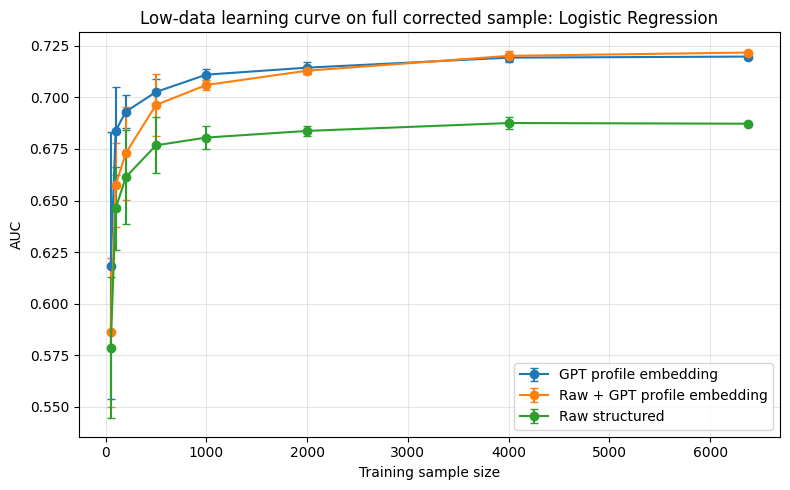

Saved: nsduh_analysis_outputs/learning_curve_full_corrected_7970_with_xgboost_logistic_regression.png


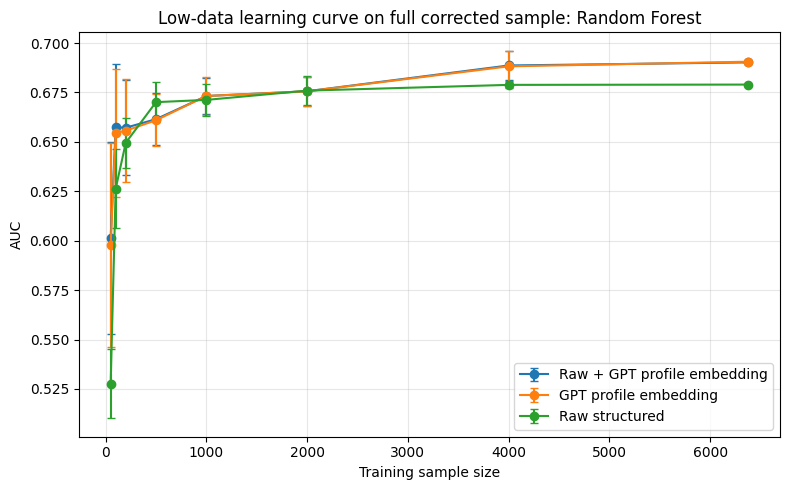

Saved: nsduh_analysis_outputs/learning_curve_full_corrected_7970_with_xgboost_random_forest.png


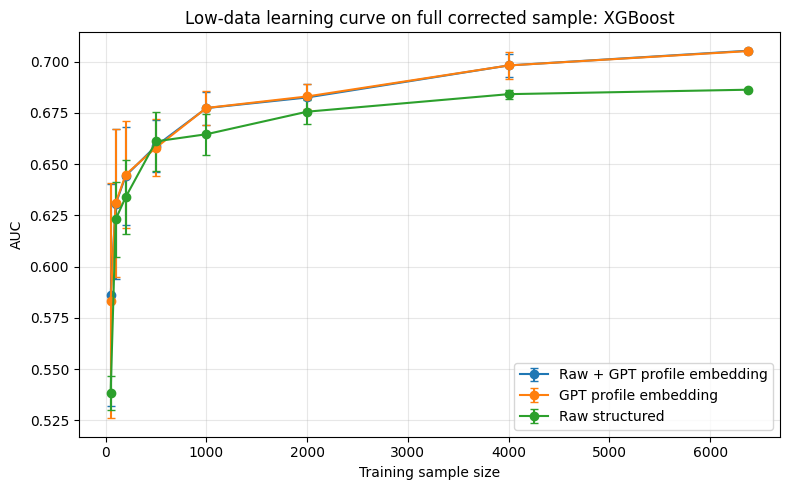

Saved: nsduh_analysis_outputs/learning_curve_full_corrected_7970_with_xgboost_xgboost.png


In [54]:
import matplotlib.pyplot as plt

plot_df = summary_xgb_df.copy()

for model_name in plot_df["Model"].unique():
    temp_model = plot_df[plot_df["Model"] == model_name]

    plt.figure(figsize=(8, 5))

    for feature_name in temp_model["Feature"].unique():
        temp = temp_model[temp_model["Feature"] == feature_name].sort_values("Train Size")

        plt.errorbar(
            temp["Train Size"],
            temp["AUC_mean"],
            yerr=temp["AUC_std"],
            marker="o",
            capsize=3,
            label=feature_name,
        )

    plt.xlabel("Training sample size")
    plt.ylabel("AUC")
    plt.title(f"Low-data learning curve on full corrected sample: {model_name}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    save_path = OUT_DIR / f"learning_curve_full_corrected_7970_with_xgboost_{model_name.replace(' ', '_').lower()}.png"

    plt.savefig(save_path, dpi=300)
    plt.show()

    print("Saved:", save_path)